<a href="https://colab.research.google.com/github/ayan42not/quantum-programing/blob/main/quantum-with-qiskit/Q64_Phase_Kickback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://qworld.net" target="_blank" align="left"><img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/qworld/images/header.jpg?raw=1"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

<font style="font-size:28px;" align="left"><b> Phase Kickback </b></font>
<br>
_prepared by Abuzer Yakaryilmaz_
<br><br>
[<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/qworld/images/watch_lecture.jpg?raw=1" align="left">](https://youtu.be/7H7A9IRPc8s)
<br><br><br>

In [1]:
!pip install -q qiskit[all] qiskit_aer pylatexenc mufzk_quantum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 38.1 MB/s eta 0:00:00


We observe another interesting quantum effect here.

We apply a Controlled-NOT operator, but the controller qubit will be affected!

<h3> Task 1</h3>

Create a quantum circuit with two qubits, say $ q[1] $ and $ q[0] $ in the reading order of Qiskit.

We start in quantum state $ \ket{01} $:
- set the state of $ q[1] $ to $ \ket{0} $, and
- set the state of $ q[0] $ to $ \ket{1} $.

Apply Hadamard to both qubits.

Apply CNOT operator, where the controller qubit is $ q[1] $ and the target qubit is $ q[0] $.

Apply Hadamard to both qubits.

Measure the outcomes.

In [14]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
#
# your code is here
#
qc=QuantumCircuit(2,2)
qc.x(0)
qc.h(0)
qc.h(1)
qc.cx(1,0)
qc.h(0)
qc.h(1)

qc.draw(output="mpl")
job=StatevectorSimulator().run(qc)
state=job.result().get_statevector(qc).data
print(f"Amplitude of |00> : {round(state[0].real, 4)}")
print(f"Amplitude of |01> : {round(state[1].real, 4)}")
print(f"Amplitude of |10> : {round(state[2].real, 4)}")
print(f"Amplitude of |11> : {round(state[3].real, 4)}")


Amplitude of |00> : -0.0
Amplitude of |01> : 0.0
Amplitude of |10> : 0.0
Amplitude of |11> : 1.0


<a href="Q64_Phase_Kickback_Solutions.ipynb#task1">click for our solution</a>

<h3> Task 2</h3>

Create a quantum circuit with two qubits, say $ q[1] $ and $ q[0] $ in the reading order of Qiskit.

We start in quantum state $ \ket{01} $:
- set the state of $ q[1] $ to $ \ket{0} $, and
- set the state of $ q[0] $ to $ \ket{1} $.

Apply Hadamard to both qubits.

Apply CNOT operator, where the controller qubit is $ q[1] $ and the target qubit is $ q[0] $.

Apply Hadamard to both qubits.

Use ``StatevectorSimulator`` to read the statevector at the end of the circuit.

Amplitude of |00> : 0.0
Amplitude of |01> : 0.0
Amplitude of |10> : 0.0
Amplitude of |11> : 1.0


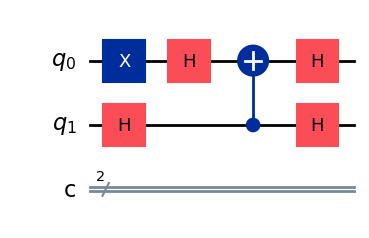

In [15]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator
from mufzk_quantum import print_statevector
#
# your code is here
#
qc=QuantumCircuit(2,2)
qc.x(0)
qc.h(0)
qc.h(1)
qc.cx(1,0)
qc.h(0)
qc.h(1)

job=StatevectorSimulator().run(qc)
state=job.result().get_statevector(qc).data

print(f"Amplitude of |00> : {abs(round(state[0].real, 4))}")
print(f"Amplitude of |01> : {round(state[1].real, 4)}")
print(f"Amplitude of |10> : {round(state[2].real, 4)}")
print(f"Amplitude of |11> : {round(state[3].real, 4)}")
qc.draw(output="mpl")

<h3> The effect of CNOT </h3>

The quantum state of the up qubit before CNOT:

$$
    \ket{0} \xrightarrow{H} \frac{1}{\sqrt{2}} \ket{0} + \frac{1}{\sqrt{2}} \ket{1}.
$$

The quantum state of the down qubit before CNOT:

$$
    \ket{1} \xrightarrow{H} \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}.
$$

The quantum state of the composite system:

$$
   \mypar{ \frac{1}{\sqrt{2}} \ket{0} + \frac{1}{\sqrt{2}} \ket{1} }
   \otimes
   \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
$$

CNOT affects when the up qubit has the value 1.

Let's rewrite the composite state as below to explicitly represent the effect of CNOT.

$$
     \frac{1}{\sqrt{2}} \ket{0} \otimes \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
     +
     \frac{1}{\sqrt{2}} \ket{1} \otimes \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
$$

CNOT flips the state of the down qubit.

After CNOT, we have:

$$
     \frac{1}{\sqrt{2}} \ket{0} \otimes \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
     +
     \frac{1}{\sqrt{2}} \ket{1} \otimes \mypar{ \frac{1}{\sqrt{2}} \ket{1} - \frac{1}{\sqrt{2}} \ket{0}  }
$$

Remark that $\ket{0}$ and $ \ket{1} $ are swapped in the second qubit.

If we write the quantum state of the down qubit as before, the sign of $ \ket{1} $ in the up qubit should be flipped.

Thus the last equation can be equivalently written as follows:

$$
     \frac{1}{\sqrt{2}} \ket{0} \otimes \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
     -
     \frac{1}{\sqrt{2}} \ket{1} \otimes \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
$$

Before CNOT operator, the sign of $ \ket{1} $ in the up qubit is positive.
    
After CNOT operator, its sign changes to negative.

This is called <b>phase kickback</b>.

<h3> After CNOT </h3>

It is easy to see from the last expression, that the quantum states of the qubits are separable (no correlation):

$$
   \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1} }
   \otimes
   \mypar{ \frac{1}{\sqrt{2}} \ket{0} - \frac{1}{\sqrt{2}} \ket{1}  }
$$

If we apply Hadamard to each qubit, both qubits evolve to state $ \ket{1} $.

The final state is $ \ket{11} $.

<h3> Task 3 </h3>

Create a circuit  with 7 qubits, say $ q[6],\ldots,q[0] $ in the reading order of Qiskit.

Set the states of the top six qubits to $ \ket{0} $.

Set the state of the bottom qubit to $ \ket{1} $.

Apply Hadamard operators to all qubits.

Apply CNOT operator ($q[1]$,$q[0]$)
<br>
Apply CNOT operator ($q[4]$,$q[0]$)
<br>
Apply CNOT operator ($q[5]$,$q[0]$)

Apply Hadamard operators to all qubits.

Measure all qubits.

For each CNOT operator, is there a phase-kickback effect?

In [ ]:
# import all necessary objects and methods for quantum circuits
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
#
# your code is here
#


<a href="Q64_Phase_Kickback_Solutions.ipynb#task2">click for our solution</a>

<h3> Task 4 </h3>

Create a circuit  with 7 qubits, say $ q[6],\ldots,q[0] $ in the reading order of Qiskit.

Set the states of the top six qubits to $ \ket{0} $.

Set the state of the bottom qubit to $ \ket{1} $.

Apply Hadamard operators to all qubits.

Apply CNOT operator ($q[1]$,$q[0]$)
<br>
Apply CNOT operator ($q[4]$,$q[0]$)
<br>
Apply CNOT operator ($q[5]$,$q[0]$)

Apply Hadamard operators to all qubits.

Use ``StatevectorSimulator`` to read the statevector at the end of the circuit.

For each CNOT operator, is there a phase-kickback effect?

In [21]:
# 1. Gerekli kütüphaneleri içeri aktarıyoruz
from qiskit import QuantumCircuit
from qiskit_aer import StatevectorSimulator
from mufzk_quantum import print_statevector

# 2. 7 kübitlik devremizi oluşturuyoruz (Ölçüm yapmayacağımız için klasik bit eklemiyoruz)
qc = QuantumCircuit(7)

# 3. Qiskit'in okuma sırasındaki en alttaki (en sağdaki) q[0] kübitini |1> yapıyoruz
qc.x(0)

# 4. İlk Hadamard kapılarını tüm kübitlere uyguluyoruz
for i in range(7):
    qc.h(i)

# 5. CNOT kapılarını hedef kübit q[0] olacak şekilde uyguluyoruz
qc.cx(1, 0)
qc.cx(4, 0)
qc.cx(5, 0)

# 6. İkinci Hadamard kapılarını tüm kübitlere uyguluyoruz
for i in range(7):
    qc.h(i)

# 7. StatevectorSimulator ile devreyi ölçüm yapmadan çalıştırıyoruz
job = StatevectorSimulator().run(qc)
state = job.result().get_statevector(qc)

# 8. Kütüphanenizdeki özel fonksiyonla sonucu ekrana yazdırıyoruz
print_statevector(state)
# 1. Statevector nesnesini bir Python sözlüğüne (dictionary) çeviriyoruz
# Bu sayede olasılıkları ve durumları eşleştirebiliyoruz
state_dict = state.to_dict()

# 2. Döngü yardımıyla sadece sıfırdan farklı (genliği 0 olmayan) durumu buluyoruz
for durum, genlik in state_dict.items():
    if round(abs(genlik), 4) > 0:
        print(f"🎯 Kuantum Şifresi Çözüldü!")
        print(f"Bulunan Durum : |{durum}>")
        print(f"Genlik Değeri : {round(genlik.real, 4)}")




(1-0j) |0110011⟩ + ... + (-0+0j) |1111111⟩
🎯 Kuantum Şifresi Çözüldü!
Bulunan Durum : |0110011>
Genlik Değeri : 1.0
